# Learning F1 Race Prediction Hypotheses using Synthetic Telemetry

## Goal

My objective with this project is to use synthetic F1 race data to hypothesize driver-related factors, and car/team-related factors that lead to podium finishes (1st-3rd) in races. The dataset contains over 233,000 training rows, packed with information about each lap/track, each team, each driver, and each car.

The dataset can be found at https://www.kaggle.com/datasets/likithagedipudi/f1-race-prediction-dataset

In [15]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,race_id,season,race_round,circuit_id,circuit_country,circuit_length_km,circuit_turns,driver_id,driver_first_name,driver_last_name,...,circuit_overtake_difficulty,circuit_base_lap_time_sec,driver_driver_code,driver_date_of_birth,team_team_name,team_team_code,team_base_country,team_engine_supplier,team_car_reliability_rating,team_pit_crew_rating
0,1,2015,1,1,Australia,5.278,14,42,Adrian,Senna,...,0.6,82.0,SEN,1991-08-09,Crimson Racing,CRI,Italy,Stallion,0.98,0.89
1,1,2015,1,1,Australia,5.278,14,30,Rio,Verstappen,...,0.6,82.0,VER,1982-03-14,Crimson Racing,CRI,Italy,Stallion,0.98,0.89
2,1,2015,1,1,Australia,5.278,14,31,Carlos,Bottas,...,0.6,82.0,BOT,1975-07-09,Silver Arrows GP,SAG,Germany,Silver,1.00,0.86
3,1,2015,1,1,Australia,5.278,14,43,Romain,Tsunoda,...,0.6,82.0,TSU,1975-06-25,Silver Arrows GP,SAG,Germany,Silver,1.00,0.86
4,1,2015,1,1,Australia,5.278,14,11,Mark,Sainz,...,0.6,82.0,SAI,1976-06-13,Azure Bull Racing,ABR,Austria,Apex,1.00,0.88


Part of the reason why I decided to go with this particular dataset is the amount of data columns(71) that not only differentiate drivers, but go into detail about each race and car

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233640 entries, 0 to 233639
Data columns (total 71 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   race_id                      233640 non-null  int64  
 1   season                       233640 non-null  int64  
 2   race_round                   233640 non-null  int64  
 3   circuit_id                   233640 non-null  int64  
 4   circuit_country              233640 non-null  object 
 5   circuit_length_km            233640 non-null  float64
 6   circuit_turns                233640 non-null  int64  
 7   driver_id                    233640 non-null  int64  
 8   driver_first_name            233640 non-null  object 
 9   driver_last_name             233640 non-null  object 
 10  driver_nationality           233640 non-null  object 
 11  driver_skill_rating          233640 non-null  float64
 12  driver_aggression_rating     233640 non-null  float64
 13 

In [17]:
df.columns

Index(['race_id', 'season', 'race_round', 'circuit_id', 'circuit_country',
       'circuit_length_km', 'circuit_turns', 'driver_id', 'driver_first_name',
       'driver_last_name', 'driver_nationality', 'driver_skill_rating',
       'driver_aggression_rating', 'driver_consistency_rating', 'team_id',
       'team_budget_tier', 'team_car_speed_rating',
       'team_car_downforce_rating', 'grid_position', 'q1_time_sec',
       'q2_time_sec', 'q3_time_sec', 'lap', 'position', 'lap_time_sec',
       's1_time_sec', 's2_time_sec', 's3_time_sec', 'tire_compound',
       'tire_age_laps', 'tire_wear_pct', 'fuel_load_kg', 'ers_deploy_pct',
       'ers_harvest_pct', 'drs_activated', 'gap_to_leader_sec',
       'gap_ahead_sec', 'gap_behind_sec', 'track_status', 'weather_current',
       'race_weather_start', 'race_air_temp_c', 'race_track_temp_c',
       'pit_stop_this_lap', 'pit_stop_duration_sec', 'pit_new_compound',
       'finish_position', 'status', 'points', 'fastest_lap', 'race_race_name',
 

## Choosing Variables that Fit the Goal

Given the sheer amount of variables to be considered, it's important to **first relate all variables to the one that matters the most, 
finishing position.** Metrics with high correlation are important to note, as well as metrics with a high negative correlation. 

Driver-centric metrics like grid(starting) position highlight a driver's ability to execute the team's strategy in qualifying, which gives their team the highest chance of success on race day. Low correlation metrics like 'points' show that the team(car+driver) performed well, causing their points to increase higher than before. Remember, low finishing position is better than a higher one, so some metrics that have a high negative correlation are useful.

As can be seen, the **driver-centric metrics most correlated to finish_position are tire_wear_pct, grid_position, and lap_time_sec**. The **team/car-centric metrics with the highest negative correlation were team_car_speed_rating, team_pit_crew_rating, and team_car_downforce_rating**. Metrics like points are contextual, meaning anyone could have been #1 in these metrics, and they don't directly affect the race. In this project we are looking for descriptive reasons as to why a car+driver wins a race on any given race day.

In [18]:
df.corr(numeric_only=True)["finish_position"].sort_values(ascending=False)

finish_position                1.000000
position                       0.846069
gap_to_leader_sec              0.484718
team_id                        0.375407
tire_wear_pct                  0.362954
grid_position                  0.315654
lap_time_sec                   0.304905
s2_time_sec                    0.300822
s1_time_sec                    0.299476
s3_time_sec                    0.294496
gap_ahead_sec                  0.149544
drs_activated                  0.112224
driver_consistency_rating      0.079493
driver_aggression_rating       0.024672
pit_stop_duration_sec          0.021050
driver_id                      0.018080
q1_time_sec                    0.016127
circuit_id                     0.010871
race_round                     0.010871
circuit_length_km              0.010352
fuel_load_kg                   0.010219
circuit_overtake_difficulty    0.009010
race_air_temp_c                0.007509
race_safety_car_deployed       0.007178
ers_harvest_pct                0.002885


## Part I: The Driver Effect

Now that I've narrowed down some variables related to finishing position, I can split this analysis into 2 parts. In part I, I am going to evaluate factors that have more to do with the driver, in order to analyze the "driver effect" on race outcome, and determine whether there even is one.

The variables I attributed to the driver below are grid_position, tire_wear_pct, and lap_time_sec.

### Grid Position evaluation

Grid position is starting position, based on the finishing order of qualifying. As stated before, I perceive it to be a driver-centric metric as it is the driver's job to execute the strategy of the team and the car in qualifying. 

**Hypothesis: The better a car+driver do in qualifying, the higher the higher the chances they have of winning the race**

In [19]:
df[["finish_position", "grid_position"]].corr()

,finish_position,grid_position
finish_position,1.000000,0.315654
grid_position,0.315654,1.000000


In [20]:
import matplotlib.pyplot as plt

As seen below, grid_position is not necessarily a definitive determining factor of race outcome. While grid_position was seen to have some correlative influence, **the scatter plot below displays that cars who started near the front of the grid(1st-3rd place) did not end up in last place, as opposed to displaying that they placed on podium, or landed at any particular part of the field.**


Text(0.5, 1.0, 'Final Position vs. Starting Position')

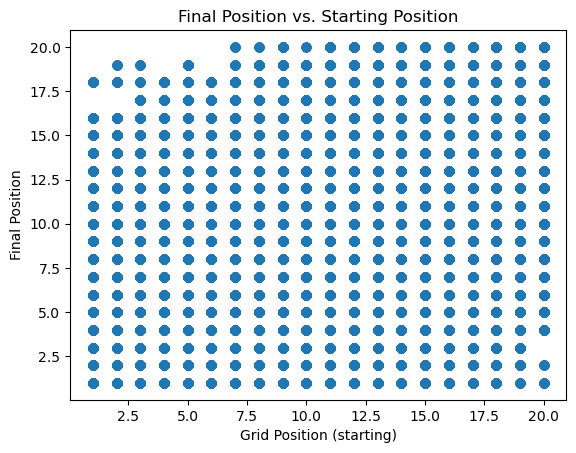

In [21]:
plt.scatter(df["grid_position"], df["finish_position"])
plt.xlabel("Grid Position (starting)")
plt.ylabel("Final Position")

plt.title("Final Position vs. Starting Position")

### Tire Wear Evaluation

Tire wear percentage(tire_wear_pct) is the percentage at which a driver wore down their car's tires. High tire wear can mean that a driver drove the car fast, but can also be a sign of an aggressive strategy, if a car is behind in the race.

**Hypothesis: The lower the tire wear percentage, the higher a car finished**

In [22]:
df.groupby("finish_position")["tire_wear_pct"].mean()

finish_position
1     30.799077
2     33.344053
3     35.666108
4     38.375560
5     40.594742
6     41.804700
7     42.804471
8     44.516288
9     45.789763
10    48.233504
11    51.958390
12    55.054829
13    59.234954
14    62.953893
15    64.443825
16    65.100437
17    65.448544
18    65.208425
19    65.430554
20    62.080481
Name: tire_wear_pct, dtype: float64

The hypothesis turned out to be mostly true, highlighting that better finishers generally had lower tire wear.

### Lap Time (seconds) Evaluation

Lap time is self explanatory, the amount of time, in seconds, it took a car to make one lap around the track. While technically based on the car+driver, it is up to the driver to execute the team/car strategy in order to achieve the lowest lap time.

**Hypothesis: The best finishing drivers+cars have the fastest lap times, on average**

In [23]:
df.groupby("finish_position")["lap_time_sec"].mean()

finish_position
1     254.547026
2     259.260455
3     262.746462
4     265.625096
5     268.293302
6     270.861771
7     273.115042
8     276.046085
9     279.618166
10    282.075086
11    284.720675
12    287.684709
13    292.218788
14    295.448538
15    298.461575
16    301.781216
17    304.357580
18    307.063714
19    310.632522
20    305.940349
Name: lap_time_sec, dtype: float64

Just like for tire wear percentage, it is seen that the best finishers generally had the fastest lap times, but the disparity between lap times is a lot less pronounced than for tire wear percentage. This can be attributed to margins between lap times being a lot thinner, and each car being fast nonetheless in an F1 race.

**From this, It can be said that tire wear percentage influences podium finishes (1st-3rd) more than lap time or grid position but does not determine it, as conservative drivers can be lower on the grid or have a better lap time than a car that finished before it.**

## Part II: The Team Effect

In part II I will evaluate team-centric variables that had a strong correlation to finishing position. The variables I attributed to teams, or each respective car, were team_car_speed_rating, team_pit_crew_rating, and team_car_downforce_rating

### Team Car Speed Rating Evaluation

Team car speed rating puts a number to how strong a car is, speed wise, compared to the grid. In F1 every team has to create their own car, so there is variation between each car's power output and strategy

**Hypothesis: Teams with the higher car speed ratings more often than not had better finishing positions**

In [24]:
df.groupby("finish_position")["team_car_speed_rating"].mean()

finish_position
1     0.889680
2     0.822179
3     0.807553
4     0.794750
5     0.791353
6     0.765253
7     0.717027
8     0.684051
9     0.667323
10    0.671206
11    0.690247
12    0.704591
13    0.738643
14    0.763531
15    0.726949
16    0.680166
17    0.639151
18    0.576615
19    0.516108
20    0.487587
Name: team_car_speed_rating, dtype: float64

As can be seen above, the data suggests that the top 5 finishing cars tend to have a higher speed rating. After that, interestingly enough, such claims cannot be made, as positions like 13-15th have a higher speed rating on average than 8-11th.

This variation in team car speed rating can be diminished by grouping finish positions by racing categories. 

**Top 3 = Podium, 4-10 = Points, 11-15 = Lower Midfield, 16-20 = Backmarkers**

In [25]:
finish_bins = [0, 3, 10, 15, 20]

finish_labels = ["Podium", "Points", "Lower Midfield", "Backmarkers"]

df["finish_group"] = pd.cut(
    df["finish_position"],
    bins=finish_bins,
    labels=finish_labels
)

It is at this point that Seaborn comes in to help me better visualize this data. While it is reasonable to say that the fastest cars do not always win the race, another visualization, like a boxplot, can help me better understand the range of team car speed ratings driving each average. 

Text(0.5, 1.0, 'Team Car Speed Rating vs. Group')

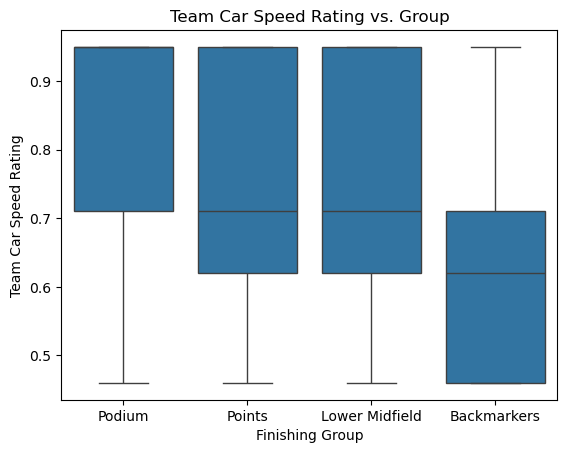

In [26]:
import seaborn as sns

sns.boxplot(x="finish_group", y="team_car_speed_rating", data=df)
plt.xlabel("Finishing Group")
plt.ylabel("Team Car Speed Rating")
plt.title("Team Car Speed Rating vs. Finishing Group")

As can be seen above the podium cars on average have a higher speed rating, giving them the edge above cars in the points or lower midfield, that have about the same speed rating distribution. Cars that are backmarkers generally have a lower speed rating, which reinforces their status as cars at the back of the pack.

Each finishing group has outliers that are either really high or really low, meaning team car speed rating alone is not a determining factor on how a car finishes.

### Team Pit Crew Rating Evaluation

The strength of each team's pit crew highlights how a car can go into the pit lane and leave quickly. This is as the quicker the pit, the quicker the lap time overall.

Once again, a box plot will be able to display the ranges of team pit crew rating based on finishing groups.

**Hypothesis: The podium cars will have a higher pit crew rating, while points and lower midfield cars will have similar pit crew distributions. Backmarkers will have the lowest pit crew rating.**

Text(0.5, 1.0, 'Team Pit Crew Rating vs. Finishing Group')

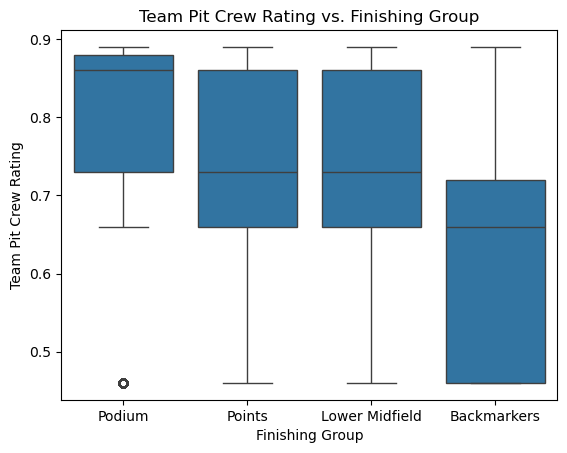

In [29]:
sns.boxplot(x="finish_group", y="team_pit_crew_rating", data=df)
plt.xlabel("Finishing Group")
plt.ylabel("Team Pit Crew Rating")
plt.title("Team Pit Crew Rating vs. Finishing Group")

Compared to team car speed, a team's pit crew rating is seen to be a lot higher on podium cars, and a lot lower on backmarkers. Once Again, teams in the points and in the lower midfield have nearly identical distributions, signalling that this part of the grid is very competitive.

### Team Car Downforce Rating Evaluation

Downforce is an aerodynamic force that keeps the F1 cars on the ground, helping with high speed cornering, braking, and tire grip.

First I will calculate the mean downforce rating based on finishing group, and then further visualize using a box plot.

**Hypothesis: Team Car Downforce Rating will have a similar distribution to team pit crew rating, where podium cars have the highest downforce rating on average, lower and midfield cars have similar distributions, and backmarkers have the lowest downforce ratings.**

In [33]:
df.groupby("finish_group", observed=True)["team_car_downforce_rating"].mean()

finish_group
Podium            0.814580
Points            0.728153
Lower Midfield    0.725376
Backmarkers       0.630969
Name: team_car_downforce_rating, dtype: float64

Text(0.5, 1.0, 'Team Car Downforce Rating vs. Finishing Group')

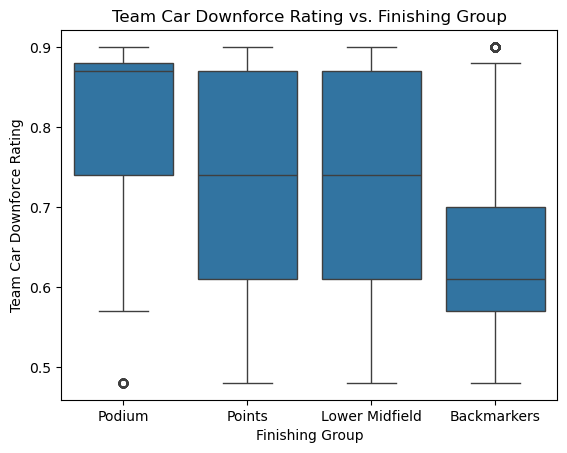

In [34]:
sns.boxplot(x="finish_group", y="team_car_downforce_rating", data=df)
plt.xlabel("Finishing Group")
plt.ylabel("Team Car Downforce Rating")
plt.title("Team Car Downforce Rating vs. Finishing Group")

The hypothesis turned out to be true, where the box distributions between pit crew rating and downforce rating were similar. The points and lower midfield boxes for downforce rating are a lot more broad than for pit crew rating, compared to the backmarkers boxes for both plots, displaying that the cars on the grid were a lot more similar when evaluating downforce rating vs. pit crew rating.

**From this, I posit that pit crew rating was a lot more of a determining factor in podium positioning than car downforce rating, but not as much as team car speed rating.**

## Conclusion

In conclusion, the data suggested a few things:

1. The driver-centric metric that had the highest influence to podium success was tire wear percentage, but does not mean that other driver-centric metrics like grid position and lap time did not have any influence.
2. Team/car-centered metrics were more linked to podium finishing than driver-centric metrics. This can be seen in disparity between the high median number for podium vs the centralized median for points and lower midfield groups for each visualized box plot, signalling that the best cars excelled in the team-centric metrics.

The largest point of all that was reinforced through the data was that many factors go into an F1 race, even a synthetic one, to a point that no single variable can be seen as a determining factor. In fact, the combination on many data points, also known as telemetry, better hypothesize a car's performance and help determine where/why it placed in a race.
